# Presentation figures — the 5-minute talk

Two figure sets for the talk, both saved to `figures/` at 300 dpi with
projection-sized fonts:

1. **The problem slide** (`pres_problem_transect.png`) — one snowy EarthCARE
   transect across Disko Bay, ~80 km from the Aasiaat gauge: *at what scale
   would both say "it is snowing"?*
2. **The ladder** (`pres_fss_ladder_1.png` … `_5.png`) — the main-result plot
   built one curve per slide, in the order of the stations notebook §3e:
   radar baseline θ=0.01 → gauge baseline θ=0.1 → high-altitude adjustment
   θ=0.3 → 850 hPa advective window → ERA5's nearest-cell point.

Inputs: `results/fss_ladder_curves.csv` (written by
`compare_earthcare_dmi_stations` §3e) and `results/era5_gauge_point_fss.csv`
(written by `compare_model_earthcare_dmi` §2) — re-run those notebooks first
if the analysis has changed. Only the transect map touches raw EO data.

## 1 · The problem slide: a chord across a circle

EarthCARE samples a nadir curtain ~1 km wide; the gauge is a point. One real
overpass makes the question concrete: the satellite sees snow along
essentially the whole track, the track never comes closer than ~80 km to the
gauge — so *at what scale should the two be expected to agree?*

The candidate table (closest approach 50–90 km, plenty of snowing profiles)
is printed so the choice is auditable; `TRANSECT_GRANULE` overrides it.

candidate transects (closest approach 50-90 km, >=30 snowing profiles):
granule                time  closest_km  n_profiles  n_snowing  max_mmhr
 07668C 2025-10-03 18:35:00        51.7         153        150      1.99
 08446C 2025-11-22 18:36:00        50.2         164        139      0.87
 05356C 2025-05-08 04:22:00        62.1         151        123      0.80
 08804C 2025-12-15 18:47:00        55.0         159        112      1.33
 04749C 2025-03-30 04:08:00        78.6         118        111      1.17
 08079C 2025-10-30 04:21:00        66.6         144        107      0.21
 03918C 2025-02-04 18:34:00        87.2          93         92      0.41
 04696C 2025-03-26 18:33:00        87.6          89         86      0.48

04749C — 2025-03-30 04:08 UTC | closest approach 78.6 km | snowing profiles <=100 km: 111 | gauge snow-phase +/-30 min: 0.0 mm


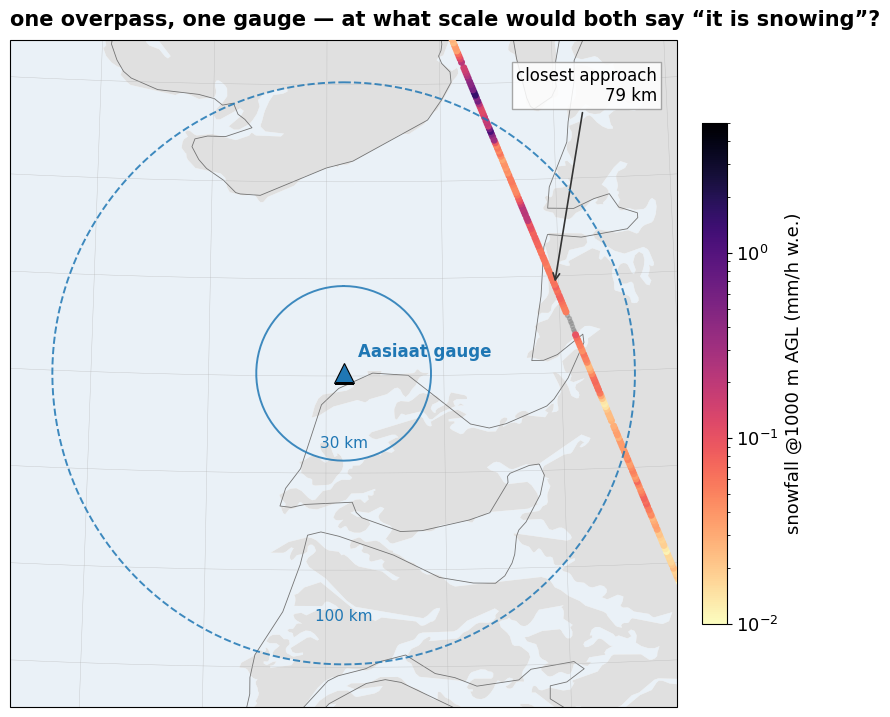

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm

sys.path.insert(0, "../src")
import eo_reader as eo
from study_config import (OUTLIER_MMHR, SNOW_PHASE_MAX_TEMP_C,
                          SNOW_THRESHOLD_MMHR, STATIONS)

# --- map styling (the analysis constants come from src/study_config.py) ---
RATE_NORM = LogNorm(vmin=0.01, vmax=5)
RATE_CMAP = "magma_r"
AASIAAT_LAT, AASIAAT_LON = (STATIONS["aasiaat"]["lat"],
                            STATIONS["aasiaat"]["lon"])
PANEL_HALF_KM = 115.0
EARTH_RADIUS_KM = 6371.0
FIG_DIR = Path("../figures")

TRANSECT_GRANULE = "04749C"     # override after inspecting the candidates below

# --- Disko EO subset: per-profile arrays and the usability screen ---
disko = eo.open_subset()
profile_rate = disko["snowfall_mmhr_1000m"].values
profile_usable = ((disko["convergence_status"].values == 0)
                  & np.isfinite(profile_rate) & (profile_rate < OUTLIER_MMHR))
profile_distance_km = disko["distance_km_422000"].values
profile_granule = disko["granule"].values
profile_lat = disko["latitude"].values
profile_lon = disko["longitude"].values
profile_time = pd.to_datetime(disko["time"].values)

# --- candidate transects: closest approach 50-90 km with real snow ---
candidate_rows = []
for granule_id in sorted(set(profile_granule[profile_usable
                                             & (profile_distance_km <= 100)])):
    in_ring = profile_usable & (profile_granule == granule_id) & (profile_distance_km <= 100)
    snowing = profile_rate[in_ring] > SNOW_THRESHOLD_MMHR
    candidate_rows.append(dict(
        granule=granule_id,
        time=pd.Series(profile_time[in_ring]).mean().round("min"),
        closest_km=round(float(profile_distance_km[in_ring].min()), 1),
        n_profiles=int(in_ring.sum()), n_snowing=int(snowing.sum()),
        max_mmhr=round(float(profile_rate[in_ring].max()), 2)))
candidates = pd.DataFrame(candidate_rows)
candidates = candidates[(candidates.closest_km.between(50, 90))
                        & (candidates.n_snowing >= 30)]
print("candidate transects (closest approach 50-90 km, >=30 snowing profiles):")
print(candidates.sort_values("n_snowing", ascending=False).head(8).to_string(index=False))


def geodesic_circle(center_lat, center_lon, radius_km, n_points=181):
    """Latitudes and longitudes of a true circle of constant great-circle
    radius around a point -- a plain lat/lon offset would be an ellipse at
    Greenland latitudes."""
    bearings = np.linspace(0, 2 * np.pi, n_points)
    angular = radius_km / EARTH_RADIUS_KM
    lat0, lon0 = np.radians(center_lat), np.radians(center_lon)
    ring_lat = np.arcsin(np.sin(lat0) * np.cos(angular)
                         + np.cos(lat0) * np.sin(angular) * np.cos(bearings))
    ring_lon = lon0 + np.arctan2(
        np.sin(bearings) * np.sin(angular) * np.cos(lat0),
        np.cos(angular) - np.sin(lat0) * np.sin(ring_lat))
    return np.degrees(ring_lat), np.degrees(ring_lon)


# --- the chosen transect: every usable profile of the granule ---
in_transect = profile_usable & (profile_granule == TRANSECT_GRANULE)
transect_lat = profile_lat[in_transect]
transect_lon = profile_lon[in_transect]
transect_rate = profile_rate[in_transect]
transect_distance_km = profile_distance_km[in_transect]
is_snowing = transect_rate > SNOW_THRESHOLD_MMHR
closest_idx = int(np.argmin(transect_distance_km))
overpass_time = pd.Series(profile_time[in_transect]).mean().round("min")

# --- what the gauge said in the +/-30 min window (the talk anecdote) ---
station_hourly = (pd.read_csv("../results/clean_422000_B.csv", parse_dates=["ts"])
                  .set_index("ts"))
gauge_snow_mmhr = (station_hourly["601"].clip(lower=0)
                   .where(station_hourly["101"] <= SNOW_PHASE_MAX_TEMP_C, 0.0))
lo, hi = overpass_time - pd.Timedelta("30min"), overpass_time + pd.Timedelta("30min")
window_stamps = station_hourly.index[(station_hourly.index > lo)
                                     & (station_hourly.index - pd.Timedelta("1h") < hi)]
gauge_window_mm = float(gauge_snow_mmhr.loc[window_stamps].dropna().sum())
print(f"\n{TRANSECT_GRANULE} — {overpass_time:%Y-%m-%d %H:%M} UTC | closest approach "
      f"{transect_distance_km[closest_idx]:.1f} km | snowing profiles <=100 km: "
      f"{int((is_snowing & (transect_distance_km <= 100)).sum())} | "
      f"gauge snow-phase +/-30 min: {gauge_window_mm:.1f} mm")

# --- plotting the map: one chord, one gauge, the collocation rings ---
with plt.rc_context({"font.size": 13}):
    panel_proj = ccrs.Stereographic(central_latitude=AASIAAT_LAT,
                                    central_longitude=AASIAAT_LON)
    fig, ax = plt.subplots(figsize=(10.5, 10),
                           subplot_kw={"projection": panel_proj})
    ax.set_extent([-PANEL_HALF_KM * 1e3, PANEL_HALF_KM * 1e3,
                   -PANEL_HALF_KM * 1e3, PANEL_HALF_KM * 1e3], crs=panel_proj)
    try:
        ax.add_feature(cfeature.OCEAN, facecolor="#eaf1f7", zorder=0)
        ax.add_feature(cfeature.LAND, facecolor="0.88", zorder=0)
        ax.coastlines(resolution="50m", linewidth=0.6, color="0.45", zorder=1)
    except Exception as exc:                # Natural Earth download can fail offline
        print("coastlines unavailable:", exc)
    ax.gridlines(linewidth=0.3, color="0.7", alpha=0.7)

    # the transect, coloured by snowfall rate (grey where no snow)
    ax.scatter(transect_lon[~is_snowing], transect_lat[~is_snowing], s=8,
               c="0.55", alpha=0.5, transform=ccrs.PlateCarree(), zorder=2)
    snow_points = ax.scatter(transect_lon[is_snowing], transect_lat[is_snowing],
                             s=16, c=transect_rate[is_snowing], cmap=RATE_CMAP,
                             norm=RATE_NORM, transform=ccrs.PlateCarree(), zorder=3)
    plt.colorbar(snow_points, ax=ax, shrink=0.65, pad=0.03,
                 label="snowfall @1000 m AGL (mm/h w.e.)")

    # the collocation rings, labelled inside the map
    for radius_km, ring_style, label_offset in [(30, "-", 0.85),
                                                (100, "--", 0.85)]:
        ring_lat, ring_lon = geodesic_circle(AASIAAT_LAT, AASIAAT_LON, radius_km)
        ax.plot(ring_lon, ring_lat, ring_style, color="tab:blue", lw=1.4,
                alpha=0.85, transform=ccrs.PlateCarree(), zorder=4)
        ax.text(AASIAAT_LON, AASIAAT_LAT - label_offset * radius_km / 111.2,
                f"{radius_km} km", transform=ccrs.PlateCarree(), fontsize=11,
                color="tab:blue", ha="center", zorder=4)

    # the gauge, and the closest-approach arrow
    ax.plot(AASIAAT_LON, AASIAAT_LAT, "^", ms=14, color="tab:blue",
            markeredgecolor="k", markeredgewidth=0.8,
            transform=ccrs.PlateCarree(), zorder=5)
    ax.text(AASIAAT_LON + 0.12, AASIAAT_LAT + 0.05, "Aasiaat gauge",
            transform=ccrs.PlateCarree(), fontsize=12, fontweight="bold",
            color="tab:blue", zorder=5)
    ax.annotate(f"closest approach\n{transect_distance_km[closest_idx]:.0f} km",
                xy=(transect_lon[closest_idx], transect_lat[closest_idx]),
                xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
                xytext=(0.97, 0.96), textcoords="axes fraction", fontsize=12,
                ha="right", va="top",
                arrowprops=dict(arrowstyle="->", color="0.2", lw=1.2),
                bbox=dict(fc="white", ec="0.6", alpha=0.85, pad=3))

    ax.set_title("one overpass, one gauge — at what scale would both say "
                 "\u201cit is snowing\u201d?", loc="left", fontsize=15,
                 fontweight="bold", pad=10)
    fig.savefig(FIG_DIR / "pres_problem_transect.png", dpi=300,
                bbox_inches="tight")
    plt.show()

## 2 · The ladder: the main result, one curve per slide

Plot *k* shows the first *k* curves of the stations notebook §3e (identical
data, styles and labels — read from `results/fss_ladder_curves.csv`), on fixed
axes so consecutive slides overlay seamlessly. Plot 5 adds ERA5's
nearest-cell point from `results/era5_gauge_point_fss.csv`, drawn at its
~25 km grid scale. One `FSS_useful threshold` line on every plot (the θ=0.3
fixed-window pairs; the 850 hPa variant differs by ≤ 0.004 — invisible at
projection scale). Each radius carries its pair count `n=` (overpasses with usable
profiles at that radius — 38 at 10 km growing to 361 at 100 km), anchored
under the lowest curve as in the stations notebook; the fixed-window curves
share these counts, since θ changes the values but never whether a pair
exists.

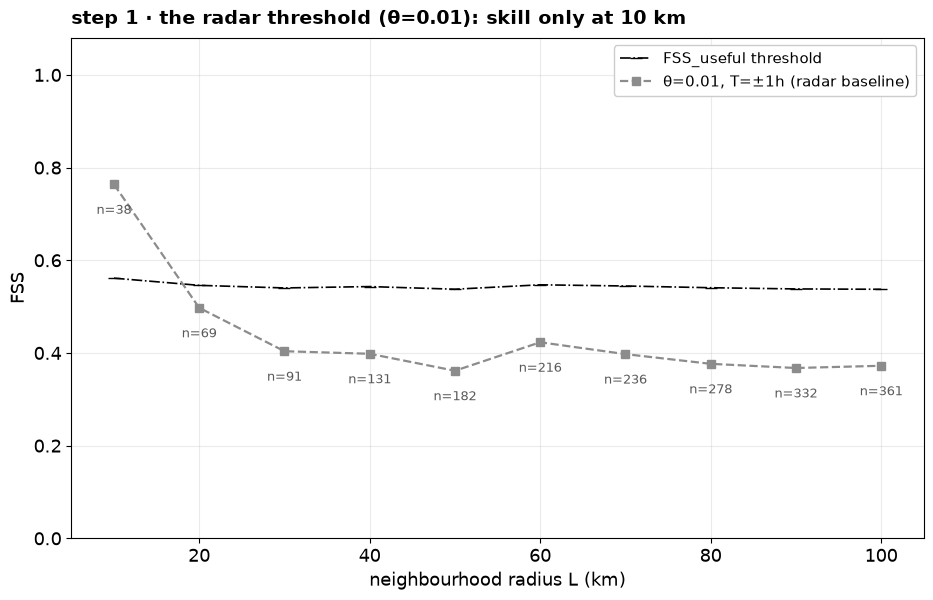

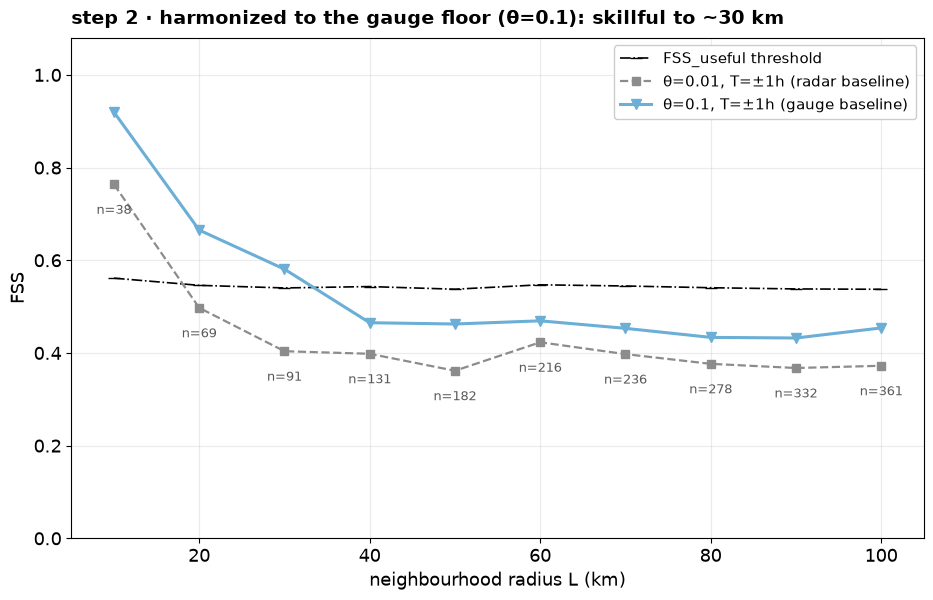

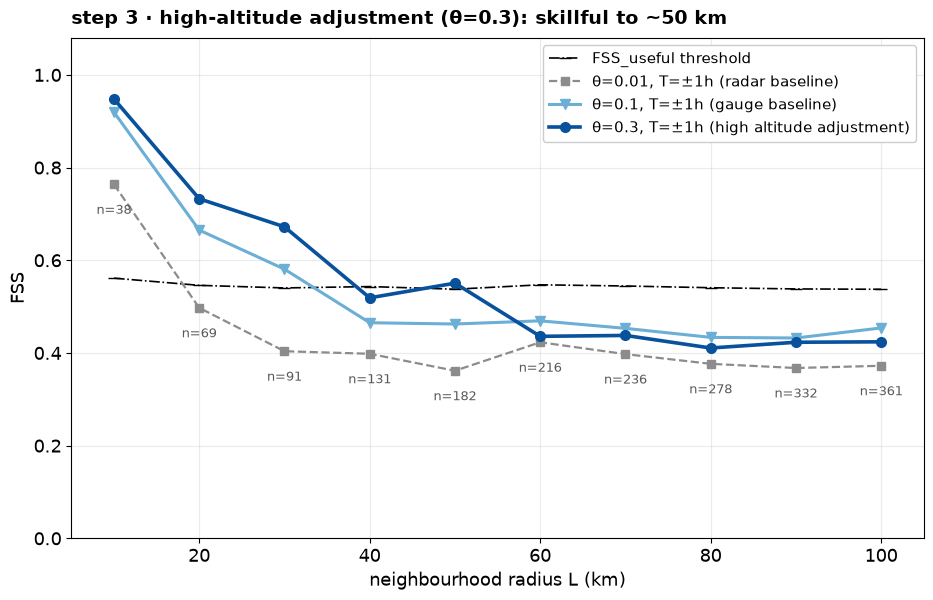

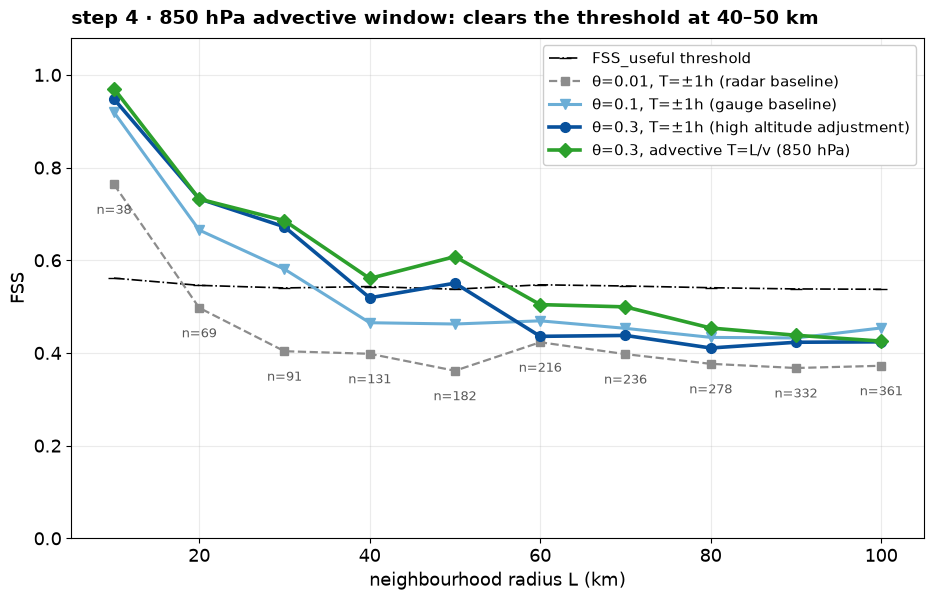

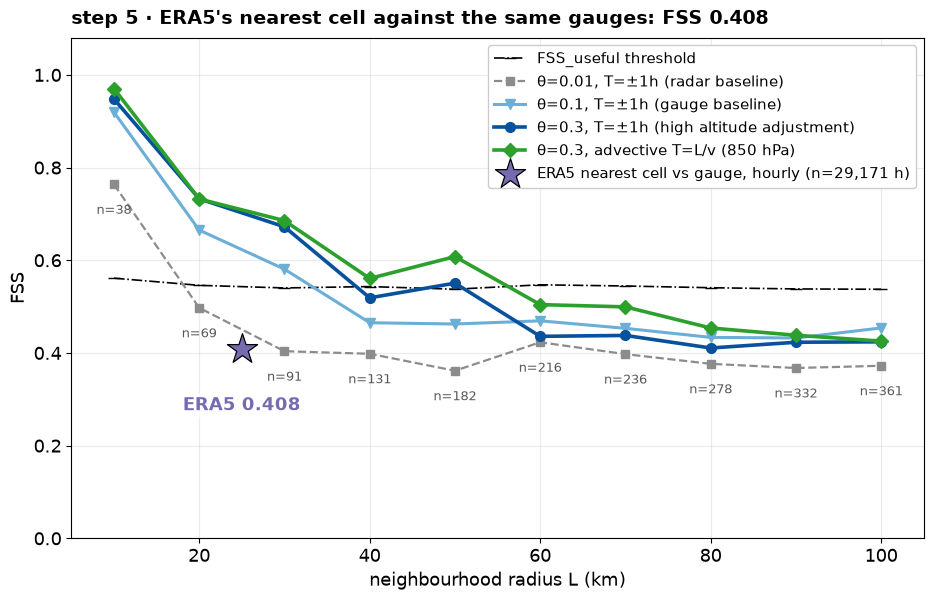

wrote pres_fss_ladder_1.png, pres_fss_ladder_2.png, pres_fss_ladder_3.png, pres_fss_ladder_4.png, pres_fss_ladder_5.png


In [2]:
# --- inputs: the 3e curves and the ERA5 point score ---
ladder = pd.read_csv("../results/fss_ladder_curves.csv")
era5_point = (pd.read_csv("../results/era5_gauge_point_fss.csv")
              .set_index("criterion").loc["exact hour"])
ERA5_NOMINAL_SCALE_KM = 25.0
ERA5_COLOR = "#756bb1"

# --- the four curves in slide order, with the 3e styles verbatim ---
CURVE_STYLES = [
    dict(color="0.55", lw=1.6, ls="--", marker="s", ms=6),      # radar baseline
    dict(color="#6baed6", lw=2.2, marker="v", ms=7),            # gauge baseline
    dict(color="#08519c", lw=2.6, marker="o", ms=7),            # high-altitude adj.
    dict(color="tab:green", lw=2.6, marker="D", ms=7),          # 850 hPa advective
]
curve_labels = (ladder.drop_duplicates("step").sort_values("step")["curve"].tolist())
curves = {label: ladder[ladder.curve == label].sort_values("L_km")
          for label in curve_labels}
radii = curves[curve_labels[0]]["L_km"].values

# one useful-skill line for every slide: the theta=0.3 fixed-window pairs
useful_line = 0.5 + curves[curve_labels[2]]["f0"].values / 2

SLIDE_TITLES = [
    "step 1 · the radar threshold (θ=0.01): skill only at 10 km",
    "step 2 · harmonized to the gauge floor (θ=0.1): skillful to ~30 km",
    "step 3 · high-altitude adjustment (θ=0.3): skillful to ~50 km",
    "step 4 · 850 hPa advective window: clears the threshold at 40–50 km",
    "step 5 · ERA5's nearest cell against the same gauges: FSS "
    f"{float(era5_point['FSS']):.3f}",
]

# --- plotting the five slides: fixed axes, one more curve each time ---
with plt.rc_context({"font.size": 13}):
    for slide in range(1, 6):
        fig, ax = plt.subplots(figsize=(11, 6.5))
        ax.plot(radii, useful_line, "k-.", lw=1.2, marker="_", ms=9,
                label="FSS_useful threshold")
        for label, style in zip(curve_labels[:min(slide, 4)], CURVE_STYLES):
            ax.plot(radii, curves[label]["FSS"].values, label=label, **style)
        if slide == 5:
            # the ERA5 point, annotated below the star (above collides with
            # the radar-baseline curve)
            era5_fss = float(era5_point["FSS"])
            ax.scatter([ERA5_NOMINAL_SCALE_KM], [era5_fss], marker="*", s=520,
                       color=ERA5_COLOR, edgecolor="k", linewidth=0.9, zorder=6,
                       label=f"ERA5 nearest cell vs gauge, hourly "
                             f"(n={int(era5_point['n_hours']):,} h)")
            ax.annotate(f"ERA5 {era5_fss:.3f}",
                        (ERA5_NOMINAL_SCALE_KM, era5_fss),
                        textcoords="offset points", xytext=(0, -34),
                        ha="center", va="top", fontsize=13, color=ERA5_COLOR,
                        fontweight="bold",
                        bbox=dict(fc="white", ec="none", alpha=0.8, pad=2))
        # pair counts (overpasses with usable profiles at that radius; the
        # fixed-window curves share them) -- anchored under the lowest curve
        # shown, which is the radar baseline at every L, so the labels sit at
        # the same spot on every slide
        n_pairs = curves[curve_labels[0]]["n_pairs"].values
        lowest_shown = np.nanmin(
            [curves[label]["FSS"].values for label in curve_labels[:min(slide, 4)]],
            axis=0)
        for radius_km, floor_value, n in zip(radii, lowest_shown, n_pairs):
            ax.annotate(f"n={n}", (radius_km, floor_value),
                        textcoords="offset points", xytext=(0, -14),
                        ha="center", va="top", fontsize=9.5, color="0.35")
        ax.set_xlim(5, 105)
        ax.set_ylim(0, 1.08)
        ax.set_xlabel("neighbourhood radius L (km)")
        ax.set_ylabel("FSS")
        ax.set_title(SLIDE_TITLES[slide - 1], loc="left", fontsize=14,
                     fontweight="bold", pad=10)
        ax.grid(alpha=0.25)
        ax.legend(fontsize=11, loc="upper right", framealpha=1)
        fig.savefig(FIG_DIR / f"pres_fss_ladder_{slide}.png", dpi=300,
                    bbox_inches="tight")
        plt.show()

print("wrote", ", ".join(f"pres_fss_ladder_{k}.png" for k in range(1, 6)))